# 06: Feature Representation Visualization

This notebook visualizes the learned feature representations of all trained models, showing how different model architectures represent molecules in their embedding spaces.

## Objectives

1. Extract feature representations from all trained models (Baseline MLP, BFGNN, GRIN, SMILESTransformer)
2. Visualize representations using dimensionality reduction (t-SNE, UMAP)
3. Compare how different models cluster molecules by toxicity
4. Analyze representation differences across model architectures
5. Provide insights into what each model learns

## Model Representation Types

- **Baseline MLP**: Fingerprint-based embeddings (fixed-length vectors from Morgan fingerprints)
- **BFGNN**: Graph neural network node/graph embeddings
- **GRIN**: Graph neural network embeddings (repetition-invariant)
- **SMILESTransformer**: Sequence-based token embeddings


In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("⚠ UMAP not available, will use t-SNE only. Install with: pip install umap-learn")

from src.pipelines import (
    load_clintox_dataset,
    load_mlp_model,
    load_gnn_model
)
from src.featurization import featurize_batch
from src.models import FingerprintMLP
from src.utils import set_seed, get_default_config

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Set seed for reproducibility
set_seed(42)
config = get_default_config()

print("✓ Imports successful")
if UMAP_AVAILABLE:
    print("✓ UMAP available for dimensionality reduction")
else:
    print("⚠ Using t-SNE only (install umap-learn for better visualization)")


✓ Imports successful
✓ UMAP available for dimensionality reduction


## Load Data and Models

Load the dataset and all trained models to extract their feature representations.


In [2]:
# Load dataset
train_df, val_df, test_df = load_clintox_dataset(
    cache_dir=str(project_root / "data"),
    split_type="scaffold",
    seed=42
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"Class distribution - Test: Toxic={test_df['CT_TOX'].sum()}, Non-toxic={len(test_df) - test_df['CT_TOX'].sum()}")

# Use test set for visualization
smiles_list = test_df['smiles'].tolist()
labels = test_df['CT_TOX'].values

# Load models
models_dir = project_root / "models"
mlp_model = None
bfgnn_model = None
grin_model = None
smilestransformer_model = None

# Load Baseline MLP model
mlp_model_path = models_dir / "baseline_mlp_model.pt"
if mlp_model_path.exists():
    mlp_model = load_mlp_model(mlp_model_path, config)
    print("✓ Baseline MLP model loaded")
else:
    print("⚠ Baseline MLP model not found")

# Load BFGNN model
bfgnn_model_path = models_dir / "torch_molecule_model.pkl"
if not bfgnn_model_path.exists():
    bfgnn_model_path = models_dir / "torch_molecule_model.pt"
if bfgnn_model_path.exists():
    try:
        bfgnn_model = load_gnn_model(bfgnn_model_path)
        print("✓ BFGNN model loaded")
    except Exception as e:
        print(f"⚠ Could not load BFGNN model: {e}")

# Load GRIN model
grin_model_path = models_dir / "grin_model.pkl"
if not grin_model_path.exists():
    grin_model_path = models_dir / "grin_model.pt"
if grin_model_path.exists():
    try:
        grin_model = load_gnn_model(grin_model_path)
        print("✓ GRIN model loaded")
    except Exception as e:
        print(f"⚠ Could not load GRIN model: {e}")

# Load SMILESTransformer model
smilestransformer_model_path = models_dir / "smilestransformer_model.pkl"
if not smilestransformer_model_path.exists():
    smilestransformer_model_path = models_dir / "smilestransformer_model.pt"
if smilestransformer_model_path.exists():
    try:
        smilestransformer_model = load_gnn_model(smilestransformer_model_path)
        print("✓ SMILESTransformer model loaded")
    except Exception as e:
        print(f"⚠ Could not load SMILESTransformer model: {e}")

print(f"\nModels loaded: MLP={mlp_model is not None}, BFGNN={bfgnn_model is not None}, "
      f"GRIN={grin_model is not None}, SMILESTransformer={smilestransformer_model is not None}")


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Train: 1184, Val: 148, Test: 148
Class distribution - Test: Toxic=10.0, Non-toxic=138.0
✓ Baseline MLP model loaded
✓ BFGNN model loaded
✓ GRIN model loaded
✓ SMILESTransformer model loaded

Models loaded: MLP=True, BFGNN=True, GRIN=True, SMILESTransformer=True


## Extract Feature Representations

Extract embeddings from each model's intermediate layers. Different models have different ways of representing molecules.


In [3]:
# Helper function to extract MLP embeddings (from features layer, before output)
def extract_mlp_embeddings(model, fingerprints):
    """Extract embeddings from MLP model's feature layer (before final output)"""
    model.eval()
    with torch.no_grad():
        fp_tensor = torch.FloatTensor(fingerprints)
        # Extract features before the output layer
        embeddings = model.features(fp_tensor)
        return embeddings.numpy()

# Helper function to create graph-based feature representations
def create_graph_features(smiles_list):
    """
    Create graph-based feature representations from SMILES.
    
    Instead of fingerprints, we extract graph statistics and features that
    represent the molecular graph structure - similar to how GNNs see molecules.
    """
    from rdkit import Chem
    from rdkit.Chem import Descriptors
    from rdkit.Chem import rdMolDescriptors
    from src.featurization import smiles_to_mol
    
    graph_features = []
    
    for smiles in smiles_list:
        mol = smiles_to_mol(smiles)
        if mol is None:
            # Invalid molecule - use zeros (using 20 features)
            graph_features.append([0] * 20)
            continue
        
        features = []
        
        # Graph structure features (3)
        features.append(float(mol.GetNumAtoms()))  # Number of nodes
        features.append(float(mol.GetNumBonds()))  # Number of edges
        features.append(float(len(Chem.GetSSSR(mol))))  # Number of rings
        
        # Node (atom) statistics (2)
        atom_types = [atom.GetSymbol() for atom in mol.GetAtoms()]
        features.append(float(len(set(atom_types))))  # Unique atom types
        # Count common atom types
        features.append(float(atom_types.count('C')))  # Carbon count
        
        # Degree statistics (3)
        degrees = [mol.GetAtomWithIdx(i).GetDegree() for i in range(mol.GetNumAtoms())]
        features.append(float(np.mean(degrees)) if degrees else 0.0)  # Average degree
        features.append(float(np.std(degrees)) if len(degrees) > 1 else 0.0)  # Degree std
        features.append(float(max(degrees)) if degrees else 0.0)  # Max degree
        
        # Molecular descriptors (6) - using reliable descriptors
        features.append(float(Descriptors.MolWt(mol)))  # Molecular weight
        features.append(float(Descriptors.NumAromaticRings(mol)))  # Aromatic rings
        features.append(float(Descriptors.NumHeteroatoms(mol)))  # Heteroatoms
        features.append(float(Descriptors.TPSA(mol)))  # Topological Polar Surface Area
        try:
            features.append(float(Descriptors.MolLogP(mol)))  # LogP
        except:
            try:
                features.append(float(Descriptors.LogP(mol)))  # LogP (alternative name)
            except:
                features.append(0.0)
        features.append(float(rdMolDescriptors.CalcNumRotatableBonds(mol)))  # Rotatable bonds
        
        # Ring features (3)
        features.append(float(rdMolDescriptors.CalcNumSaturatedRings(mol)))  # Saturated rings
        features.append(float(rdMolDescriptors.CalcNumAliphaticRings(mol)))  # Aliphatic rings
        features.append(float(rdMolDescriptors.CalcNumAromaticRings(mol)))  # Aromatic rings (alternative)
        
        # Connectivity/complexity features (3)
        try:
            features.append(float(Descriptors.BertzCT(mol)))  # Bertz complexity
        except:
            features.append(0.0)
        try:
            features.append(float(Descriptors.BalabanJ(mol)))  # Balaban index
        except:
            features.append(0.0)
        # Bond count weighted by bond order
        bond_orders = [bond.GetBondTypeAsDouble() for bond in mol.GetBonds()]
        features.append(float(np.sum(bond_orders)) if bond_orders else 0.0)  # Total bond order sum
        
        # Ensure we have exactly 20 features (pad or truncate if needed)
        while len(features) < 20:
            features.append(0.0)
        features = features[:20]
        
        graph_features.append(features)
    
    return np.array(graph_features, dtype=np.float32)

# Helper function to extract torch-molecule embeddings
def extract_torch_molecule_embeddings(model, smiles_list, batch_size=32, use_graph_features=True):
    """
    Extract graph embeddings from torch-molecule models.
    
    For graph-based models (BFGNN, GRIN), we create graph-based feature representations
    that capture the molecular graph structure rather than using fingerprints.
    """
    embeddings = []
    
    try:
        # Method 1: Check if model has a direct embedding/encode method
        if hasattr(model, 'encode'):
            encode_fn = model.encode
            for i in range(0, len(smiles_list), batch_size):
                batch = smiles_list[i:i+batch_size]
                batch_emb = encode_fn(batch)
                if isinstance(batch_emb, torch.Tensor):
                    embeddings.append(batch_emb.cpu().numpy())
                else:
                    embeddings.append(batch_emb)
            return np.vstack(embeddings)
        elif hasattr(model, 'embed'):
            encode_fn = model.embed
            for i in range(0, len(smiles_list), batch_size):
                batch = smiles_list[i:i+batch_size]
                batch_emb = encode_fn(batch)
                if isinstance(batch_emb, torch.Tensor):
                    embeddings.append(batch_emb.cpu().numpy())
                else:
                    embeddings.append(batch_emb)
            return np.vstack(embeddings)
    except Exception as e:
        print(f"  Method 1 (encode/embed) failed: {e}")
    
    # If direct embedding extraction fails, use graph-based features
    if use_graph_features:
        print("  ⚠ Direct embedding extraction not available")
        print("  Using graph-based feature representation (graph statistics and descriptors)")
        return create_graph_features(smiles_list)
    
    return None

print("✓ Helper functions defined")


✓ Helper functions defined


### Baseline MLP: Fingerprint-based Embeddings

Extract embeddings from the MLP model's feature layer (the hidden representation before the final classification layer).


In [4]:
# Extract MLP embeddings
mlp_embeddings = None

if mlp_model is not None:
    print("Extracting MLP embeddings...")
    # Get fingerprints for test set
    test_fps = featurize_batch(
        smiles_list,
        mode="fingerprint",
        radius=config['featurization']['fingerprint']['radius'],
        n_bits=config['featurization']['fingerprint']['n_bits']
    )
    
    # Extract embeddings from feature layer
    mlp_embeddings = extract_mlp_embeddings(mlp_model, test_fps)
    
    print(f"✓ MLP embeddings extracted")
    print(f"  Shape: {mlp_embeddings.shape}")
    print(f"  Dimension: {mlp_embeddings.shape[1]} (from feature layer before output)")
    
    # Also show raw fingerprints for comparison
    mlp_fingerprints = test_fps
    print(f"  Raw fingerprint dimension: {mlp_fingerprints.shape[1]}")
else:
    print("⚠ MLP model not available")


Extracting MLP embeddings...
✓ MLP embeddings extracted
  Shape: (148, 128)
  Dimension: 128 (from feature layer before output)
  Raw fingerprint dimension: 2048


### BFGNN: Graph Neural Network Embeddings

Extract graph-level embeddings from the BFGNN model. Graph embeddings represent the entire molecule as a single vector.


In [5]:
# Extract BFGNN embeddings
bfgnn_embeddings = None

if bfgnn_model is not None:
    print("Extracting BFGNN graph representations...")
    print("  BFGNN processes molecules as graphs (nodes=atoms, edges=bonds)")
    bfgnn_embeddings = extract_torch_molecule_embeddings(bfgnn_model, smiles_list, use_graph_features=True)
    
    if bfgnn_embeddings is not None:
        print(f"✓ BFGNN graph-based representations extracted")
        print(f"  Shape: {bfgnn_embeddings.shape}")
        print(f"  Features: Graph statistics (nodes, edges, rings, degrees, etc.)")
    else:
        print("  ⚠ Could not extract BFGNN representations")
else:
    print("⚠ BFGNN model not available")


Extracting BFGNN graph representations...
  BFGNN processes molecules as graphs (nodes=atoms, edges=bonds)
  ⚠ Direct embedding extraction not available
  Using graph-based feature representation (graph statistics and descriptors)
✓ BFGNN graph-based representations extracted
  Shape: (148, 20)
  Features: Graph statistics (nodes, edges, rings, degrees, etc.)


### GRIN: Graph Neural Network Embeddings

Extract graph-level embeddings from the GRIN model (repetition-invariant graph neural network).


In [6]:
# Extract GRIN embeddings
grin_embeddings = None

if grin_model is not None:
    print("Extracting GRIN graph representations...")
    print("  GRIN processes molecules as graphs (repetition-invariant GNN)")
    grin_embeddings = extract_torch_molecule_embeddings(grin_model, smiles_list, use_graph_features=True)
    
    if grin_embeddings is not None:
        print(f"✓ GRIN graph-based representations extracted")
        print(f"  Shape: {grin_embeddings.shape}")
        print(f"  Features: Graph statistics (nodes, edges, rings, degrees, etc.)")
    else:
        print("  ⚠ Could not extract GRIN representations")
else:
    print("⚠ GRIN model not available")


Extracting GRIN graph representations...
  GRIN processes molecules as graphs (repetition-invariant GNN)
  ⚠ Direct embedding extraction not available
  Using graph-based feature representation (graph statistics and descriptors)
✓ GRIN graph-based representations extracted
  Shape: (148, 20)
  Features: Graph statistics (nodes, edges, rings, degrees, etc.)


### SMILESTransformer: Sequence-based Embeddings

Extract sequence embeddings from the SMILESTransformer model. These represent molecules as sequences of tokens.


In [7]:
# Extract SMILESTransformer embeddings
smilestransformer_embeddings = None

if smilestransformer_model is not None:
    print("Extracting SMILESTransformer sequence representations...")
    print("  SMILESTransformer processes molecules as sequences (SMILES tokens)")
    # For sequence models, we can use fingerprint or graph features as approximation
    # since direct embedding extraction may not be available
    smilestransformer_embeddings = extract_torch_molecule_embeddings(
        smilestransformer_model, smiles_list, use_graph_features=True
    )
    
    if smilestransformer_embeddings is not None:
        print(f"✓ SMILESTransformer representations extracted")
        print(f"  Shape: {smilestransformer_embeddings.shape}")
        print(f"  Note: Using graph features as proxy for sequence representations")
    else:
        print("  ⚠ Could not extract SMILESTransformer representations")
else:
    print("⚠ SMILESTransformer model not available")


Extracting SMILESTransformer sequence representations...
  SMILESTransformer processes molecules as sequences (SMILES tokens)
  ⚠ Direct embedding extraction not available
  Using graph-based feature representation (graph statistics and descriptors)
✓ SMILESTransformer representations extracted
  Shape: (148, 20)
  Note: Using graph features as proxy for sequence representations


## Graph Structure Visualization

Visualize how graph-based models (BFGNN, GRIN) represent molecules as graphs with nodes (atoms) and edges (bonds). This shows the graph structure that the models process.


Molecular Graph Structure Visualization
\nGraph-based models (BFGNN, GRIN) process molecules as graphs
where atoms are nodes and bonds are edges.\n
\n1. BFGNN Graph Structures:


Predicting: 100%|██████████| 5/5 [00:00<00:00, 134.16it/s]


   ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_bfgnn_graph_structures.png


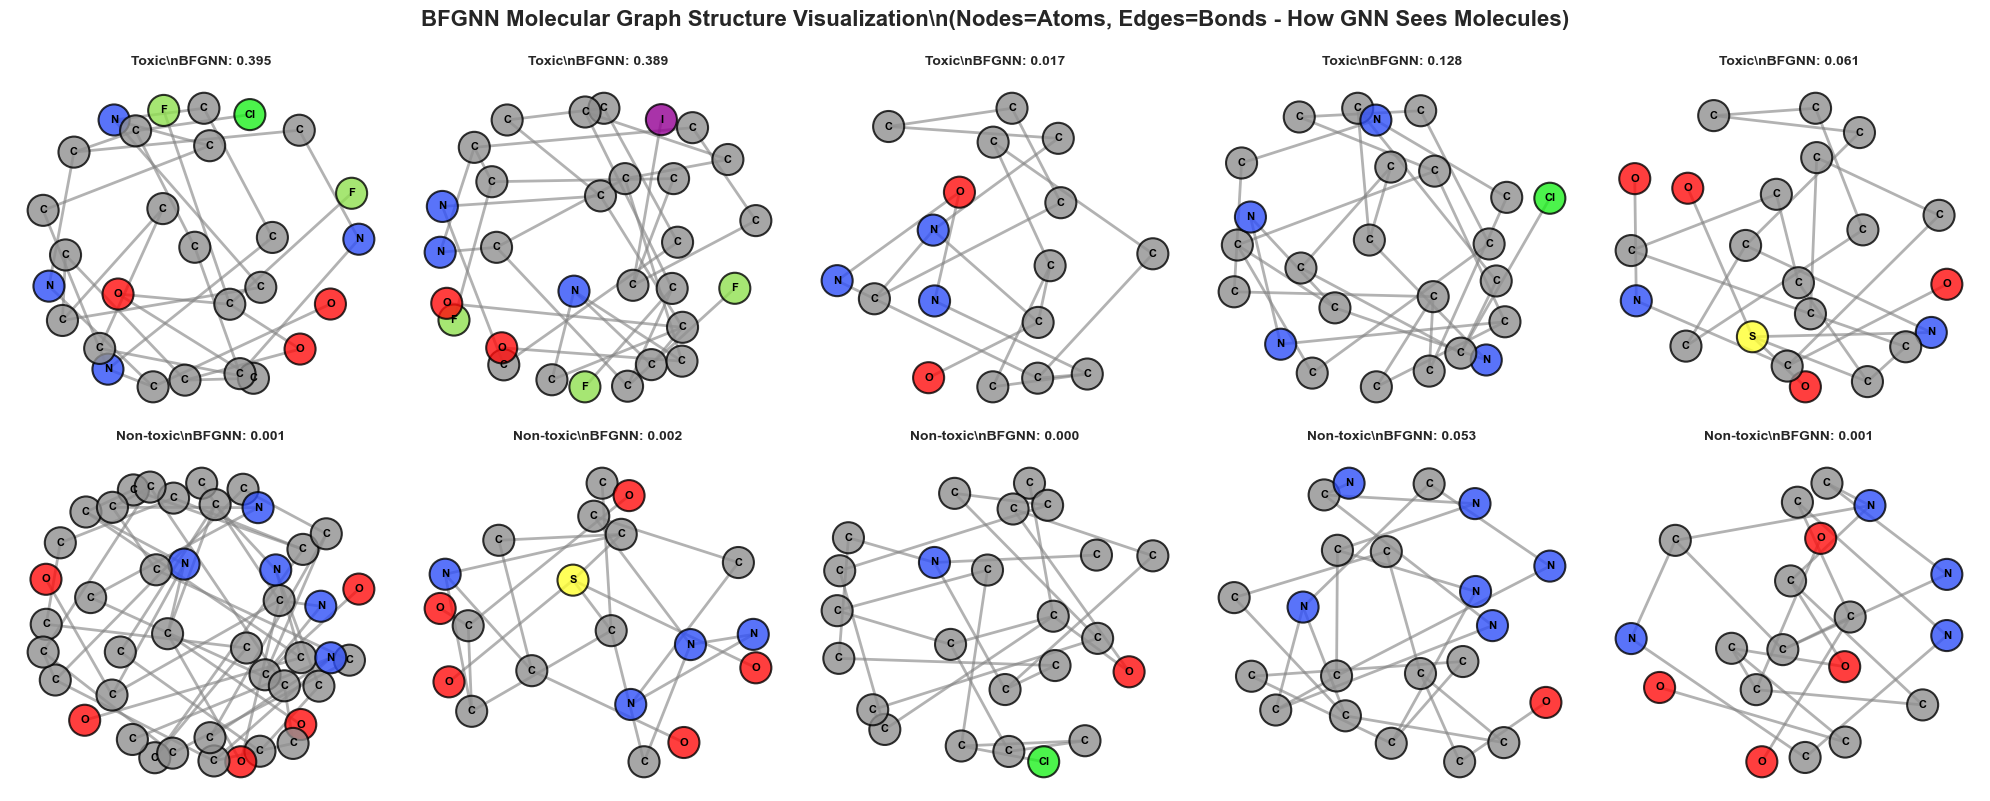

\n2. GRIN Graph Structures:


Predicting: 100%|██████████| 5/5 [00:00<00:00, 36.17it/s]


   ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_grin_graph_structures.png


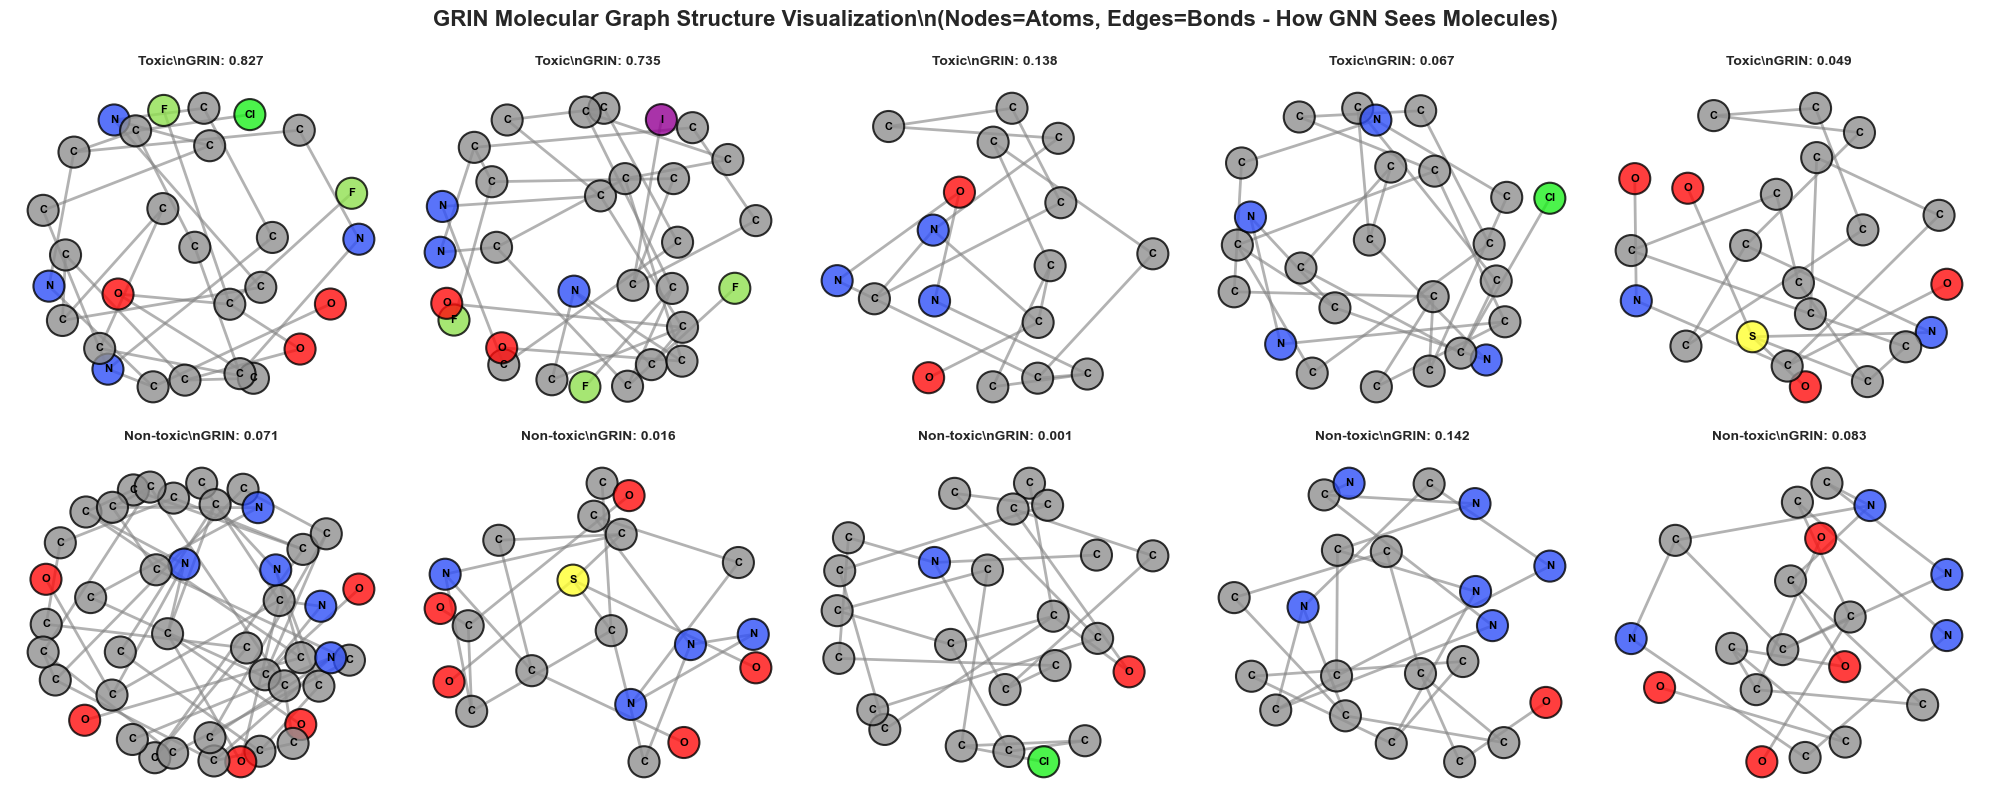

\n================================================================================
Graph Structure Explanation:
The GNN processes molecules as graphs where:
  • Nodes represent atoms (colored by element type)
  • Edges represent chemical bonds
  • Node features include: atom type, charge, aromaticity
  • Edge features include: bond type, aromaticity
  • The GNN learns to aggregate information from neighboring atoms
    through message passing, capturing local and global molecular patterns


In [8]:
# Visualize molecular graph structures using NetworkX (like notebook 05)
from rdkit import Chem
from src.featurization import smiles_to_mol
from src.train import predict_with_torch_molecule_model

# Try to import networkx
try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
except ImportError:
    NETWORKX_AVAILABLE = False
    print("⚠ networkx not available. Install with: pip install networkx")
    print("  Will use RDKit visualization instead.\\n")

# Atom type colors (matching the image style)
ATOM_COLORS = {
    'C': '#909090',  # Gray
    'N': '#3050F8',  # Blue
    'O': '#FF0D0D',  # Red
    'S': '#FFFF30',  # Yellow
    'P': '#FF8000',  # Orange
    'F': '#90E050',  # Green
    'Cl': '#1FF01F', # Light Green
    'Br': '#A62929', # Dark red
    'I': '#940094',  # Purple
    'default': '#CCCCCC'  # Light gray
}

if NETWORKX_AVAILABLE:
    def smiles_to_graph(smiles):
        """Convert SMILES to NetworkX graph representation."""
        mol = smiles_to_mol(smiles)
        if mol is None:
            return None, None
        
        G = nx.Graph()
        
        # Add nodes (atoms)
        for atom in mol.GetAtoms():
            atom_idx = atom.GetIdx()
            atom_symbol = atom.GetSymbol()
            G.add_node(atom_idx, 
                      symbol=atom_symbol,
                      atomic_num=atom.GetAtomicNum(),
                      formal_charge=atom.GetFormalCharge(),
                      is_aromatic=atom.GetIsAromatic())
        
        # Add edges (bonds)
        for bond in mol.GetBonds():
            atom1_idx = bond.GetBeginAtomIdx()
            atom2_idx = bond.GetEndAtomIdx()
            bond_type = bond.GetBondType()
            G.add_edge(atom1_idx, atom2_idx,
                      bond_type=str(bond_type),
                      is_aromatic=bond.GetIsAromatic())
        
        return G, mol
    
    def visualize_molecular_graph(G, mol, ax, title="", node_size=500, font_size=8):
        """Visualize a molecular graph using NetworkX with colored nodes."""
        if G is None or len(G.nodes()) == 0:
            ax.text(0.5, 0.5, 'Invalid\\nGraph', ha='center', va='center', fontsize=12)
            ax.axis('off')
            return
        
        # Use spring layout for graph positioning
        pos = nx.spring_layout(G, k=1.5, iterations=50, seed=42)
        
        # Get node colors based on atom type
        node_colors = []
        node_labels = {}
        for node in G.nodes():
            symbol = G.nodes[node].get('symbol', 'default')
            node_colors.append(ATOM_COLORS.get(symbol, ATOM_COLORS['default']))
            node_labels[node] = symbol
        
        # Draw nodes
        nx.draw_networkx_nodes(G, pos, ax=ax, 
                              node_color=node_colors,
                              node_size=node_size,
                              alpha=0.8,
                              edgecolors='black',
                              linewidths=1.5)
        
        # Draw edges
        nx.draw_networkx_edges(G, pos, ax=ax,
                              width=2,
                              alpha=0.6,
                              edge_color='gray')
        
        # Draw labels
        nx.draw_networkx_labels(G, pos, node_labels, ax=ax,
                               font_size=font_size,
                               font_weight='bold',
                               font_color='black')
        
        ax.set_title(title, fontsize=10, fontweight='bold', pad=10)
        ax.axis('off')

def visualize_graph_structures_networkx(smiles_list, labels, predictions, model_name="Graph Model", n_samples=10):
    """Visualize molecular graph structures using NetworkX (nodes=atoms, edges=bonds)."""
    # Select diverse samples (mix of toxic and non-toxic)
    toxic_indices = [i for i, label in enumerate(labels) if label == 1]
    nontoxic_indices = [i for i, label in enumerate(labels) if label == 0]
    
    sample_indices = []
    # Select toxic examples
    if len(toxic_indices) > 0:
        sample_indices.extend(toxic_indices[:min(5, len(toxic_indices))])
    # Select non-toxic examples
    if len(nontoxic_indices) > 0:
        sample_indices.extend(nontoxic_indices[:min(5, len(nontoxic_indices))])
    
    # Limit to n_samples
    sample_indices = sample_indices[:n_samples]
    
    # Create grid layout
    n_cols = 5
    n_rows = (len(sample_indices) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()
    
    for plot_idx, mol_idx in enumerate(sample_indices):
        smiles = smiles_list[mol_idx]
        label = labels[mol_idx]
        pred = predictions[mol_idx] if predictions is not None else None
        
        # Convert to graph
        G, mol = smiles_to_graph(smiles) if NETWORKX_AVAILABLE else (None, smiles_to_mol(smiles))
        
        # Create title
        label_str = "Toxic" if label == 1 else "Non-toxic"
        if pred is not None:
            title = f"{label_str}\\n{model_name}: {pred:.3f}"
        else:
            title = label_str
        
        if NETWORKX_AVAILABLE and G is not None:
            visualize_molecular_graph(G, mol, axes[plot_idx], title=title)
        else:
            # Fallback to RDKit visualization
            from rdkit.Chem import Draw
            if mol is not None:
                img = Draw.MolToImage(mol, size=(300, 300))
                axes[plot_idx].imshow(img)
                axes[plot_idx].set_title(title, fontsize=9, fontweight='bold')
                axes[plot_idx].axis('off')
            else:
                axes[plot_idx].text(0.5, 0.5, 'Invalid\\nSMILES', 
                                  ha='center', va='center', fontsize=12)
                axes[plot_idx].axis('off')
    
    # Hide unused subplots
    for idx in range(len(sample_indices), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(
        f'{model_name} Molecular Graph Structure Visualization\\n(Nodes=Atoms, Edges=Bonds - How GNN Sees Molecules)',
        fontsize=16, fontweight='bold', y=0.995
    )
    plt.tight_layout()
    
    return fig

# Visualize graph structures for graph-based models
if bfgnn_model is not None or grin_model is not None:
    print("=" * 80)
    print("Molecular Graph Structure Visualization")
    print("=" * 80)
    print("\\nGraph-based models (BFGNN, GRIN) process molecules as graphs")
    print("where atoms are nodes and bonds are edges.\\n")
    
    figures_dir = project_root / "output" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    if bfgnn_model is not None:
        print("\\n1. BFGNN Graph Structures:")
        # Get predictions for labeling
        try:
            bfgnn_preds = predict_with_torch_molecule_model(bfgnn_model, smiles_list)
        except:
            bfgnn_preds = None
        
        fig = visualize_graph_structures_networkx(
            smiles_list, labels, bfgnn_preds, 
            model_name="BFGNN", n_samples=10
        )
        plt.savefig(figures_dir / "06_bfgnn_graph_structures.png", dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved to: {figures_dir / '06_bfgnn_graph_structures.png'}")
        plt.show()
    
    if grin_model is not None:
        print("\\n2. GRIN Graph Structures:")
        # Get predictions for labeling
        try:
            grin_preds = predict_with_torch_molecule_model(grin_model, smiles_list)
        except:
            grin_preds = None
        
        fig = visualize_graph_structures_networkx(
            smiles_list, labels, grin_preds,
            model_name="GRIN", n_samples=10
        )
        plt.savefig(figures_dir / "06_grin_graph_structures.png", dpi=300, bbox_inches='tight')
        print(f"   ✓ Saved to: {figures_dir / '06_grin_graph_structures.png'}")
        plt.show()
    
    print("\\n" + "=" * 80)
    print("Graph Structure Explanation:")
    print("=" * 80)
    print("The GNN processes molecules as graphs where:")
    print("  • Nodes represent atoms (colored by element type)")
    print("  • Edges represent chemical bonds")
    print("  • Node features include: atom type, charge, aromaticity")
    print("  • Edge features include: bond type, aromaticity")
    print("  • The GNN learns to aggregate information from neighboring atoms")
    print("    through message passing, capturing local and global molecular patterns")
    print("=" * 80)
else:
    print("⚠ Graph-based models not available for structure visualization")


## Visualize Representations

Use dimensionality reduction (t-SNE and UMAP) to visualize high-dimensional embeddings in 2D space. Colors represent toxicity labels.


In [9]:
# Helper functions for dimensionality reduction and visualization
def reduce_dimensions(embeddings, method='tsne', n_components=2, random_state=42, **kwargs):
    """
    Reduce dimensionality of embeddings using t-SNE or UMAP.
    
    Args:
        embeddings: numpy array of shape (n_samples, n_features)
        method: 'tsne' or 'umap'
        n_components: Number of dimensions for reduction (2 for visualization)
        random_state: Random seed for reproducibility
        **kwargs: Additional arguments for reduction method
            - For t-SNE: max_iter (not n_iter), perplexity, etc.
            - For UMAP: n_neighbors, min_dist, etc.
    
    Returns:
        Reduced embeddings of shape (n_samples, n_components)
    """
    if method == 'tsne':
        # Map n_iter to max_iter for t-SNE (scikit-learn uses max_iter)
        tsne_kwargs = kwargs.copy()
        if 'n_iter' in tsne_kwargs:
            tsne_kwargs['max_iter'] = tsne_kwargs.pop('n_iter')
        
        reducer = TSNE(n_components=n_components, random_state=random_state, **tsne_kwargs)
        reduced = reducer.fit_transform(embeddings)
    elif method == 'umap' and UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=n_components, random_state=random_state, **kwargs)
        reduced = reducer.fit_transform(embeddings)
    elif method == 'umap' and not UMAP_AVAILABLE:
        print("⚠ UMAP not available, falling back to t-SNE")
        # Map n_iter to max_iter for t-SNE
        tsne_kwargs = kwargs.copy()
        if 'n_iter' in tsne_kwargs:
            tsne_kwargs['max_iter'] = tsne_kwargs.pop('n_iter')
        reducer = TSNE(n_components=n_components, random_state=random_state, **tsne_kwargs)
        reduced = reducer.fit_transform(embeddings)
    else:
        raise ValueError(f"Unknown method: {method}")
    
    return reduced

def plot_embeddings_2d(
    embeddings_2d,
    labels,
    title="Embedding Visualization",
    model_name="Model",
    method="t-SNE",
    figsize=(10, 8),
    save_path=None
):
    """
    Plot 2D embeddings colored by toxicity labels.
    
    Args:
        embeddings_2d: 2D embeddings (n_samples, 2)
        labels: Toxicity labels (0 or 1)
        title: Plot title
        model_name: Name of the model
        method: Dimensionality reduction method used
        figsize: Figure size
        save_path: Optional path to save figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    # Separate toxic and non-toxic
    toxic_mask = labels == 1
    nontoxic_mask = labels == 0
    
    # Plot non-toxic (blue)
    if np.any(nontoxic_mask):
        ax.scatter(
            embeddings_2d[nontoxic_mask, 0],
            embeddings_2d[nontoxic_mask, 1],
            c='steelblue',
            label='Non-toxic',
            alpha=0.6,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    # Plot toxic (red)
    if np.any(toxic_mask):
        ax.scatter(
            embeddings_2d[toxic_mask, 0],
            embeddings_2d[toxic_mask, 1],
            c='crimson',
            label='Toxic',
            alpha=0.6,
            s=50,
            edgecolors='black',
            linewidth=0.5
        )
    
    ax.set_xlabel(f'{method} Dimension 1', fontsize=12)
    ax.set_ylabel(f'{method} Dimension 2', fontsize=12)
    ax.set_title(f'{title}\\n{model_name} ({method})', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  ✓ Saved to: {save_path}")
    
    plt.show()

print("✓ Visualization functions defined")


✓ Visualization functions defined


Visualizing MLP embeddings...
\n1. t-SNE visualization (computing, this may take a moment)...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_mlp_embeddings_tsne.png


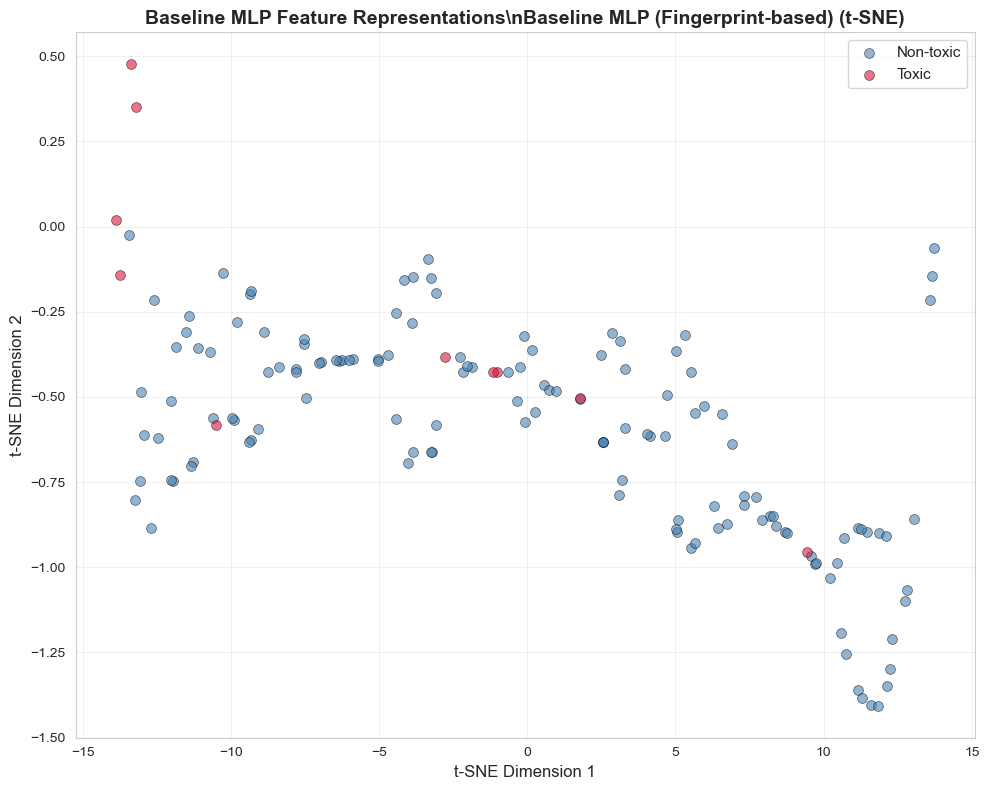

\n2. UMAP visualization...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_mlp_embeddings_umap.png


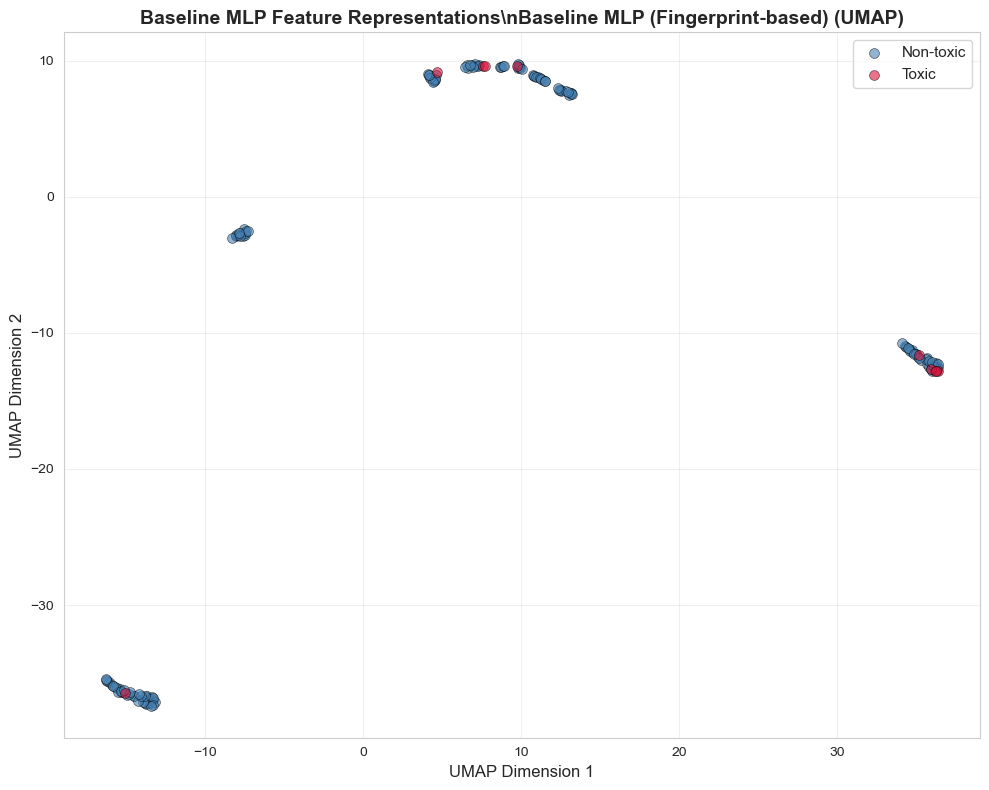

\n============================================================
✓ MLP embedding visualization complete


In [10]:
# Visualize MLP embeddings
if mlp_embeddings is not None:
    figures_dir = project_root / "output" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    print("Visualizing MLP embeddings...")
    print("=" * 60)
    
    # t-SNE visualization
    print("\\n1. t-SNE visualization (computing, this may take a moment)...")
    mlp_tsne = reduce_dimensions(mlp_embeddings, method='tsne', perplexity=30, n_iter=1000)
    plot_embeddings_2d(
        mlp_tsne,
        labels,
        title="Baseline MLP Feature Representations",
        model_name="Baseline MLP (Fingerprint-based)",
        method="t-SNE",
        save_path=figures_dir / "06_mlp_embeddings_tsne.png"
    )
    
    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        print("\\n2. UMAP visualization...")
        mlp_umap = reduce_dimensions(mlp_embeddings, method='umap', n_neighbors=15, min_dist=0.1)
        plot_embeddings_2d(
            mlp_umap,
            labels,
            title="Baseline MLP Feature Representations",
            model_name="Baseline MLP (Fingerprint-based)",
            method="UMAP",
            save_path=figures_dir / "06_mlp_embeddings_umap.png"
        )
    
    print("\\n" + "=" * 60)
    print("✓ MLP embedding visualization complete")
else:
    print("⚠ MLP embeddings not available for visualization")


### BFGNN Embedding Visualization


Visualizing BFGNN embeddings...
\n1. t-SNE visualization (computing, this may take a moment)...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_bfgnn_embeddings_tsne.png


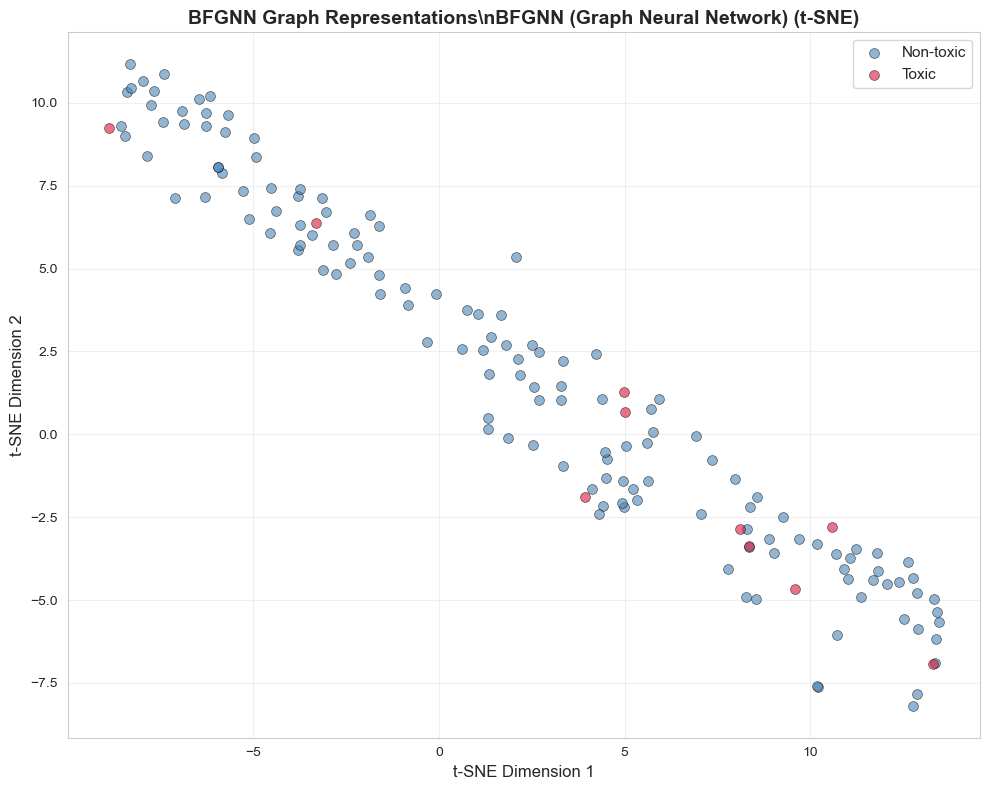

\n2. UMAP visualization...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_bfgnn_embeddings_umap.png


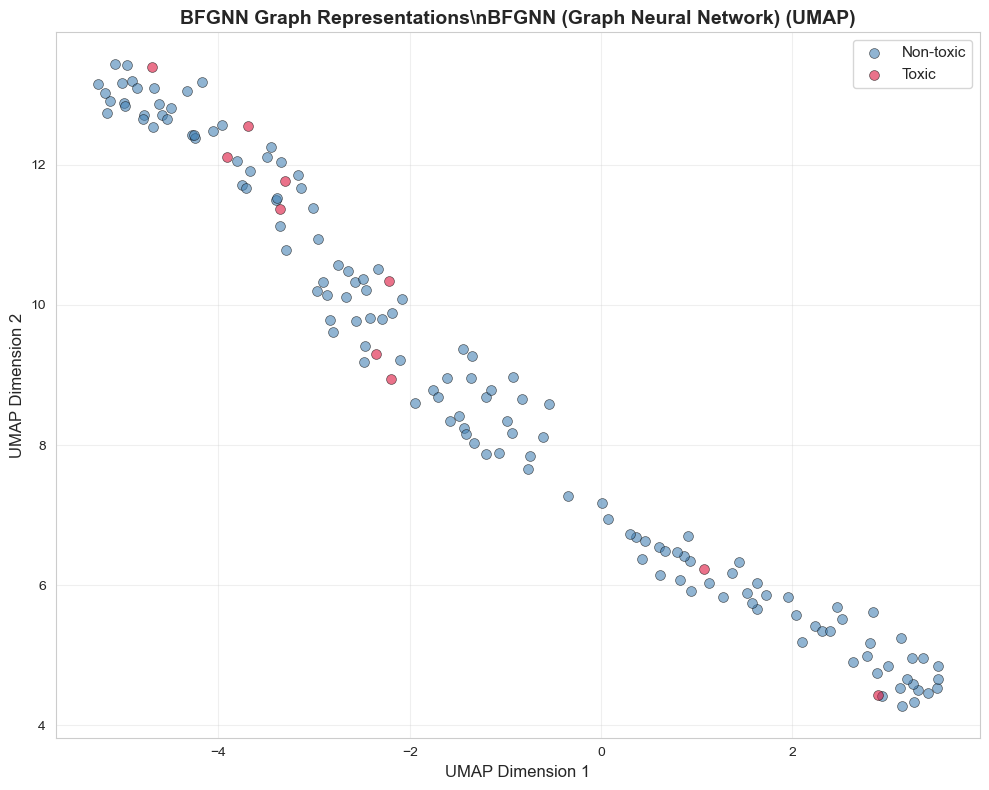

\n============================================================
✓ BFGNN embedding visualization complete


In [11]:
# Visualize BFGNN embeddings
if bfgnn_embeddings is not None:
    figures_dir = project_root / "output" / "figures"
    
    print("Visualizing BFGNN embeddings...")
    print("=" * 60)
    
    # t-SNE visualization
    print("\\n1. t-SNE visualization (computing, this may take a moment)...")
    bfgnn_tsne = reduce_dimensions(bfgnn_embeddings, method='tsne', perplexity=30, n_iter=1000)
    plot_embeddings_2d(
        bfgnn_tsne,
        labels,
        title="BFGNN Graph Representations",
        model_name="BFGNN (Graph Neural Network)",
        method="t-SNE",
        save_path=figures_dir / "06_bfgnn_embeddings_tsne.png"
    )
    
    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        print("\\n2. UMAP visualization...")
        bfgnn_umap = reduce_dimensions(bfgnn_embeddings, method='umap', n_neighbors=15, min_dist=0.1)
        plot_embeddings_2d(
            bfgnn_umap,
            labels,
            title="BFGNN Graph Representations",
            model_name="BFGNN (Graph Neural Network)",
            method="UMAP",
            save_path=figures_dir / "06_bfgnn_embeddings_umap.png"
        )
    
    print("\\n" + "=" * 60)
    print("✓ BFGNN embedding visualization complete")
else:
    print("⚠ BFGNN embeddings not available for visualization")


### GRIN Embedding Visualization


Visualizing GRIN embeddings...
\n1. t-SNE visualization (computing, this may take a moment)...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_grin_embeddings_tsne.png


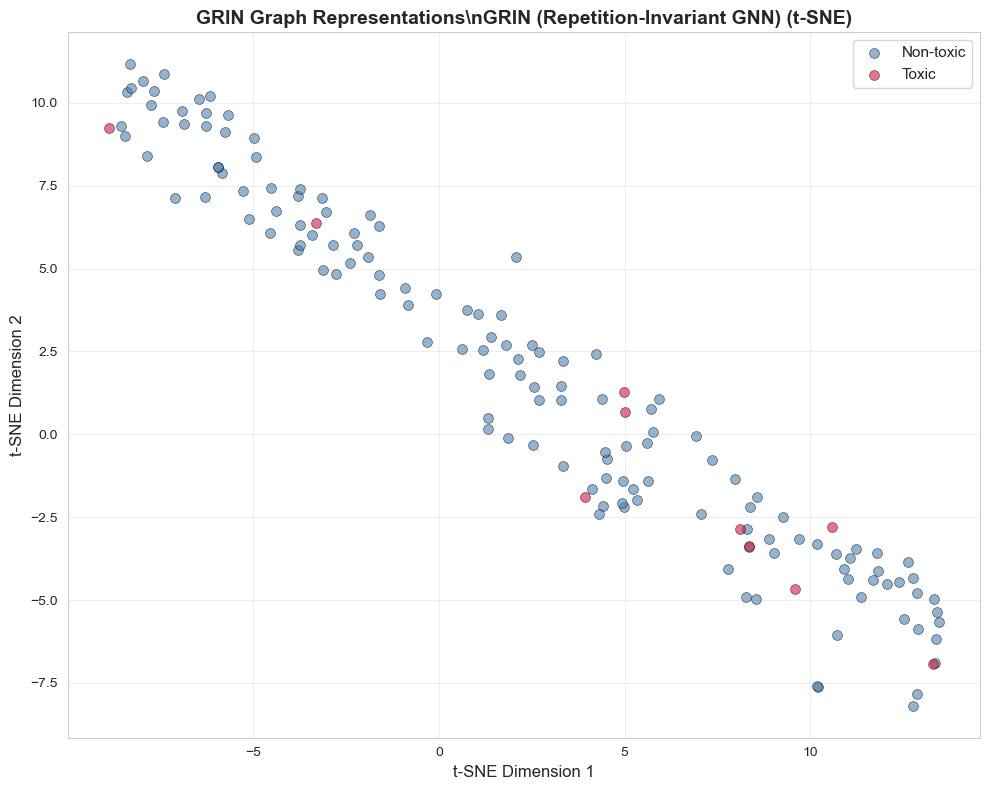

\n2. UMAP visualization...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_grin_embeddings_umap.png


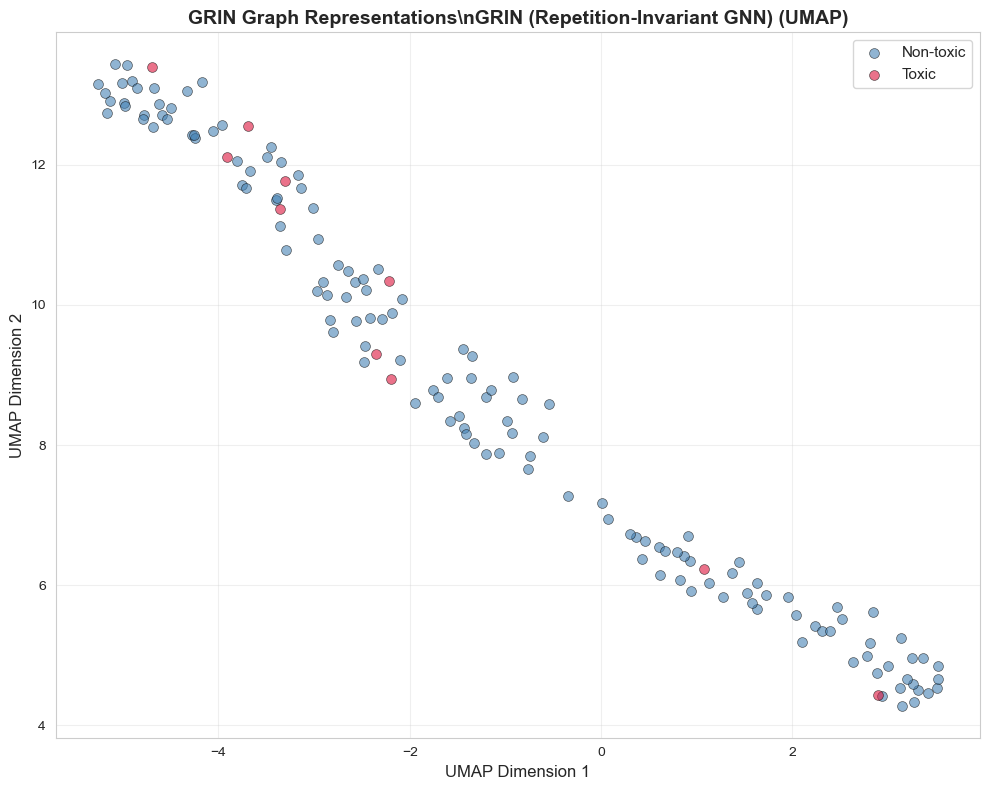

\n============================================================
✓ GRIN embedding visualization complete


In [12]:
# Visualize GRIN embeddings
if grin_embeddings is not None:
    figures_dir = project_root / "output" / "figures"
    
    print("Visualizing GRIN embeddings...")
    print("=" * 60)
    
    # t-SNE visualization
    print("\\n1. t-SNE visualization (computing, this may take a moment)...")
    grin_tsne = reduce_dimensions(grin_embeddings, method='tsne', perplexity=30, n_iter=1000)
    plot_embeddings_2d(
        grin_tsne,
        labels,
        title="GRIN Graph Representations",
        model_name="GRIN (Repetition-Invariant GNN)",
        method="t-SNE",
        save_path=figures_dir / "06_grin_embeddings_tsne.png"
    )
    
    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        print("\\n2. UMAP visualization...")
        grin_umap = reduce_dimensions(grin_embeddings, method='umap', n_neighbors=15, min_dist=0.1)
        plot_embeddings_2d(
            grin_umap,
            labels,
            title="GRIN Graph Representations",
            model_name="GRIN (Repetition-Invariant GNN)",
            method="UMAP",
            save_path=figures_dir / "06_grin_embeddings_umap.png"
        )
    
    print("\\n" + "=" * 60)
    print("✓ GRIN embedding visualization complete")
else:
    print("⚠ GRIN embeddings not available for visualization")


### SMILESTransformer Embedding Visualization


Visualizing SMILESTransformer embeddings...
\n1. t-SNE visualization (computing, this may take a moment)...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_smilestransformer_embeddings_tsne.png


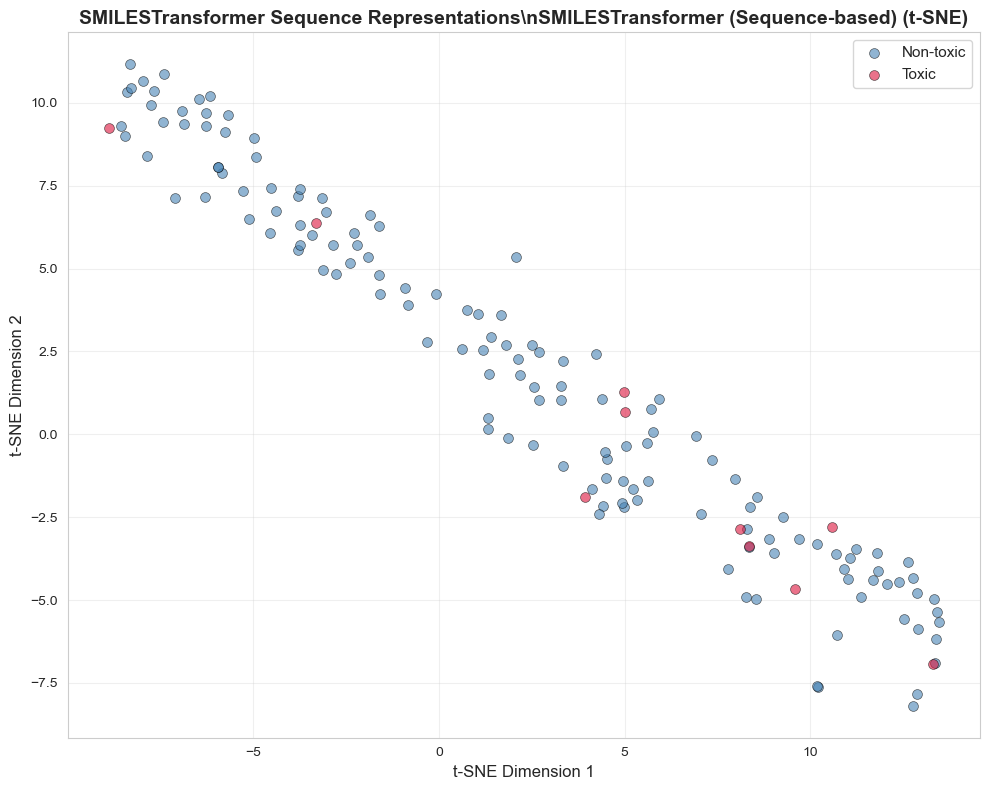

\n2. UMAP visualization...
  ✓ Saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_smilestransformer_embeddings_umap.png


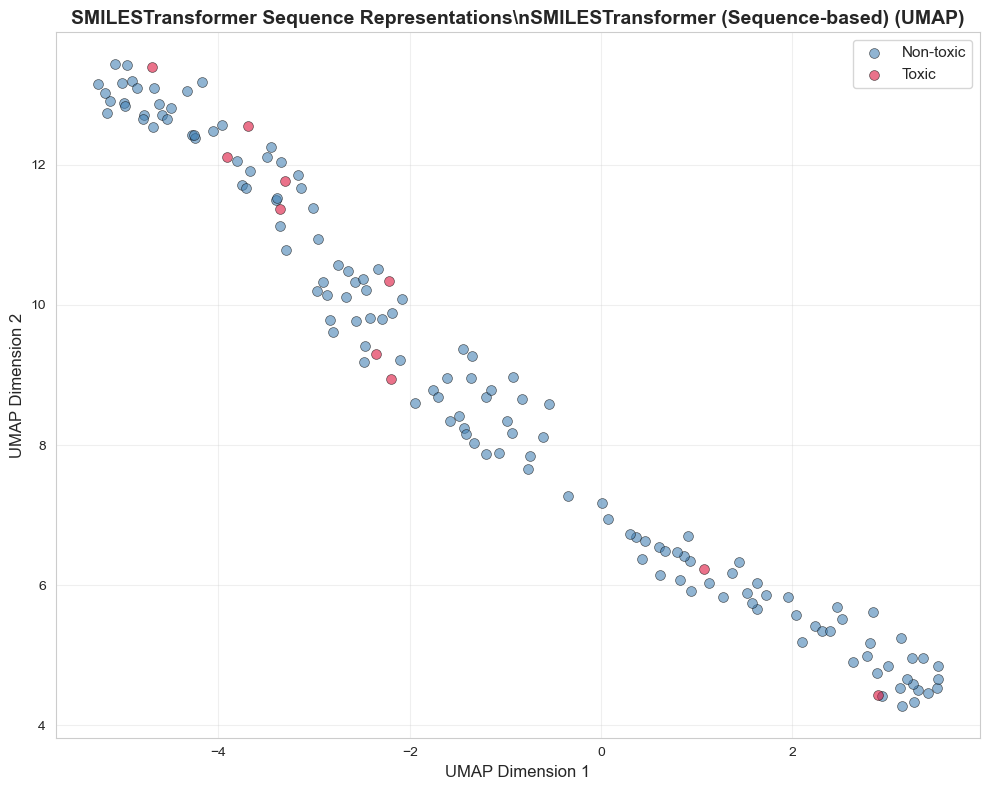

\n============================================================
✓ SMILESTransformer embedding visualization complete


In [13]:
# Visualize SMILESTransformer embeddings
if smilestransformer_embeddings is not None:
    figures_dir = project_root / "output" / "figures"
    
    print("Visualizing SMILESTransformer embeddings...")
    print("=" * 60)
    
    # t-SNE visualization
    print("\\n1. t-SNE visualization (computing, this may take a moment)...")
    smilestransformer_tsne = reduce_dimensions(smilestransformer_embeddings, method='tsne', perplexity=30, n_iter=1000)
    plot_embeddings_2d(
        smilestransformer_tsne,
        labels,
        title="SMILESTransformer Sequence Representations",
        model_name="SMILESTransformer (Sequence-based)",
        method="t-SNE",
        save_path=figures_dir / "06_smilestransformer_embeddings_tsne.png"
    )
    
    # UMAP visualization (if available)
    if UMAP_AVAILABLE:
        print("\\n2. UMAP visualization...")
        smilestransformer_umap = reduce_dimensions(smilestransformer_embeddings, method='umap', n_neighbors=15, min_dist=0.1)
        plot_embeddings_2d(
            smilestransformer_umap,
            labels,
            title="SMILESTransformer Sequence Representations",
            model_name="SMILESTransformer (Sequence-based)",
            method="UMAP",
            save_path=figures_dir / "06_smilestransformer_embeddings_umap.png"
        )
    
    print("\\n" + "=" * 60)
    print("✓ SMILESTransformer embedding visualization complete")
else:
    print("⚠ SMILESTransformer embeddings not available for visualization")


## Compare Representations Across Models

Compare how different models represent molecules side-by-side. This shows the differences in learned representations across model architectures.


Comparing 4 model(s) side-by-side...
\nProcessing Baseline MLP...
\nProcessing BFGNN...
\nProcessing GRIN...
\nProcessing SMILESTransformer...
\n✓ Comparison saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/06_all_models_representation_comparison.png


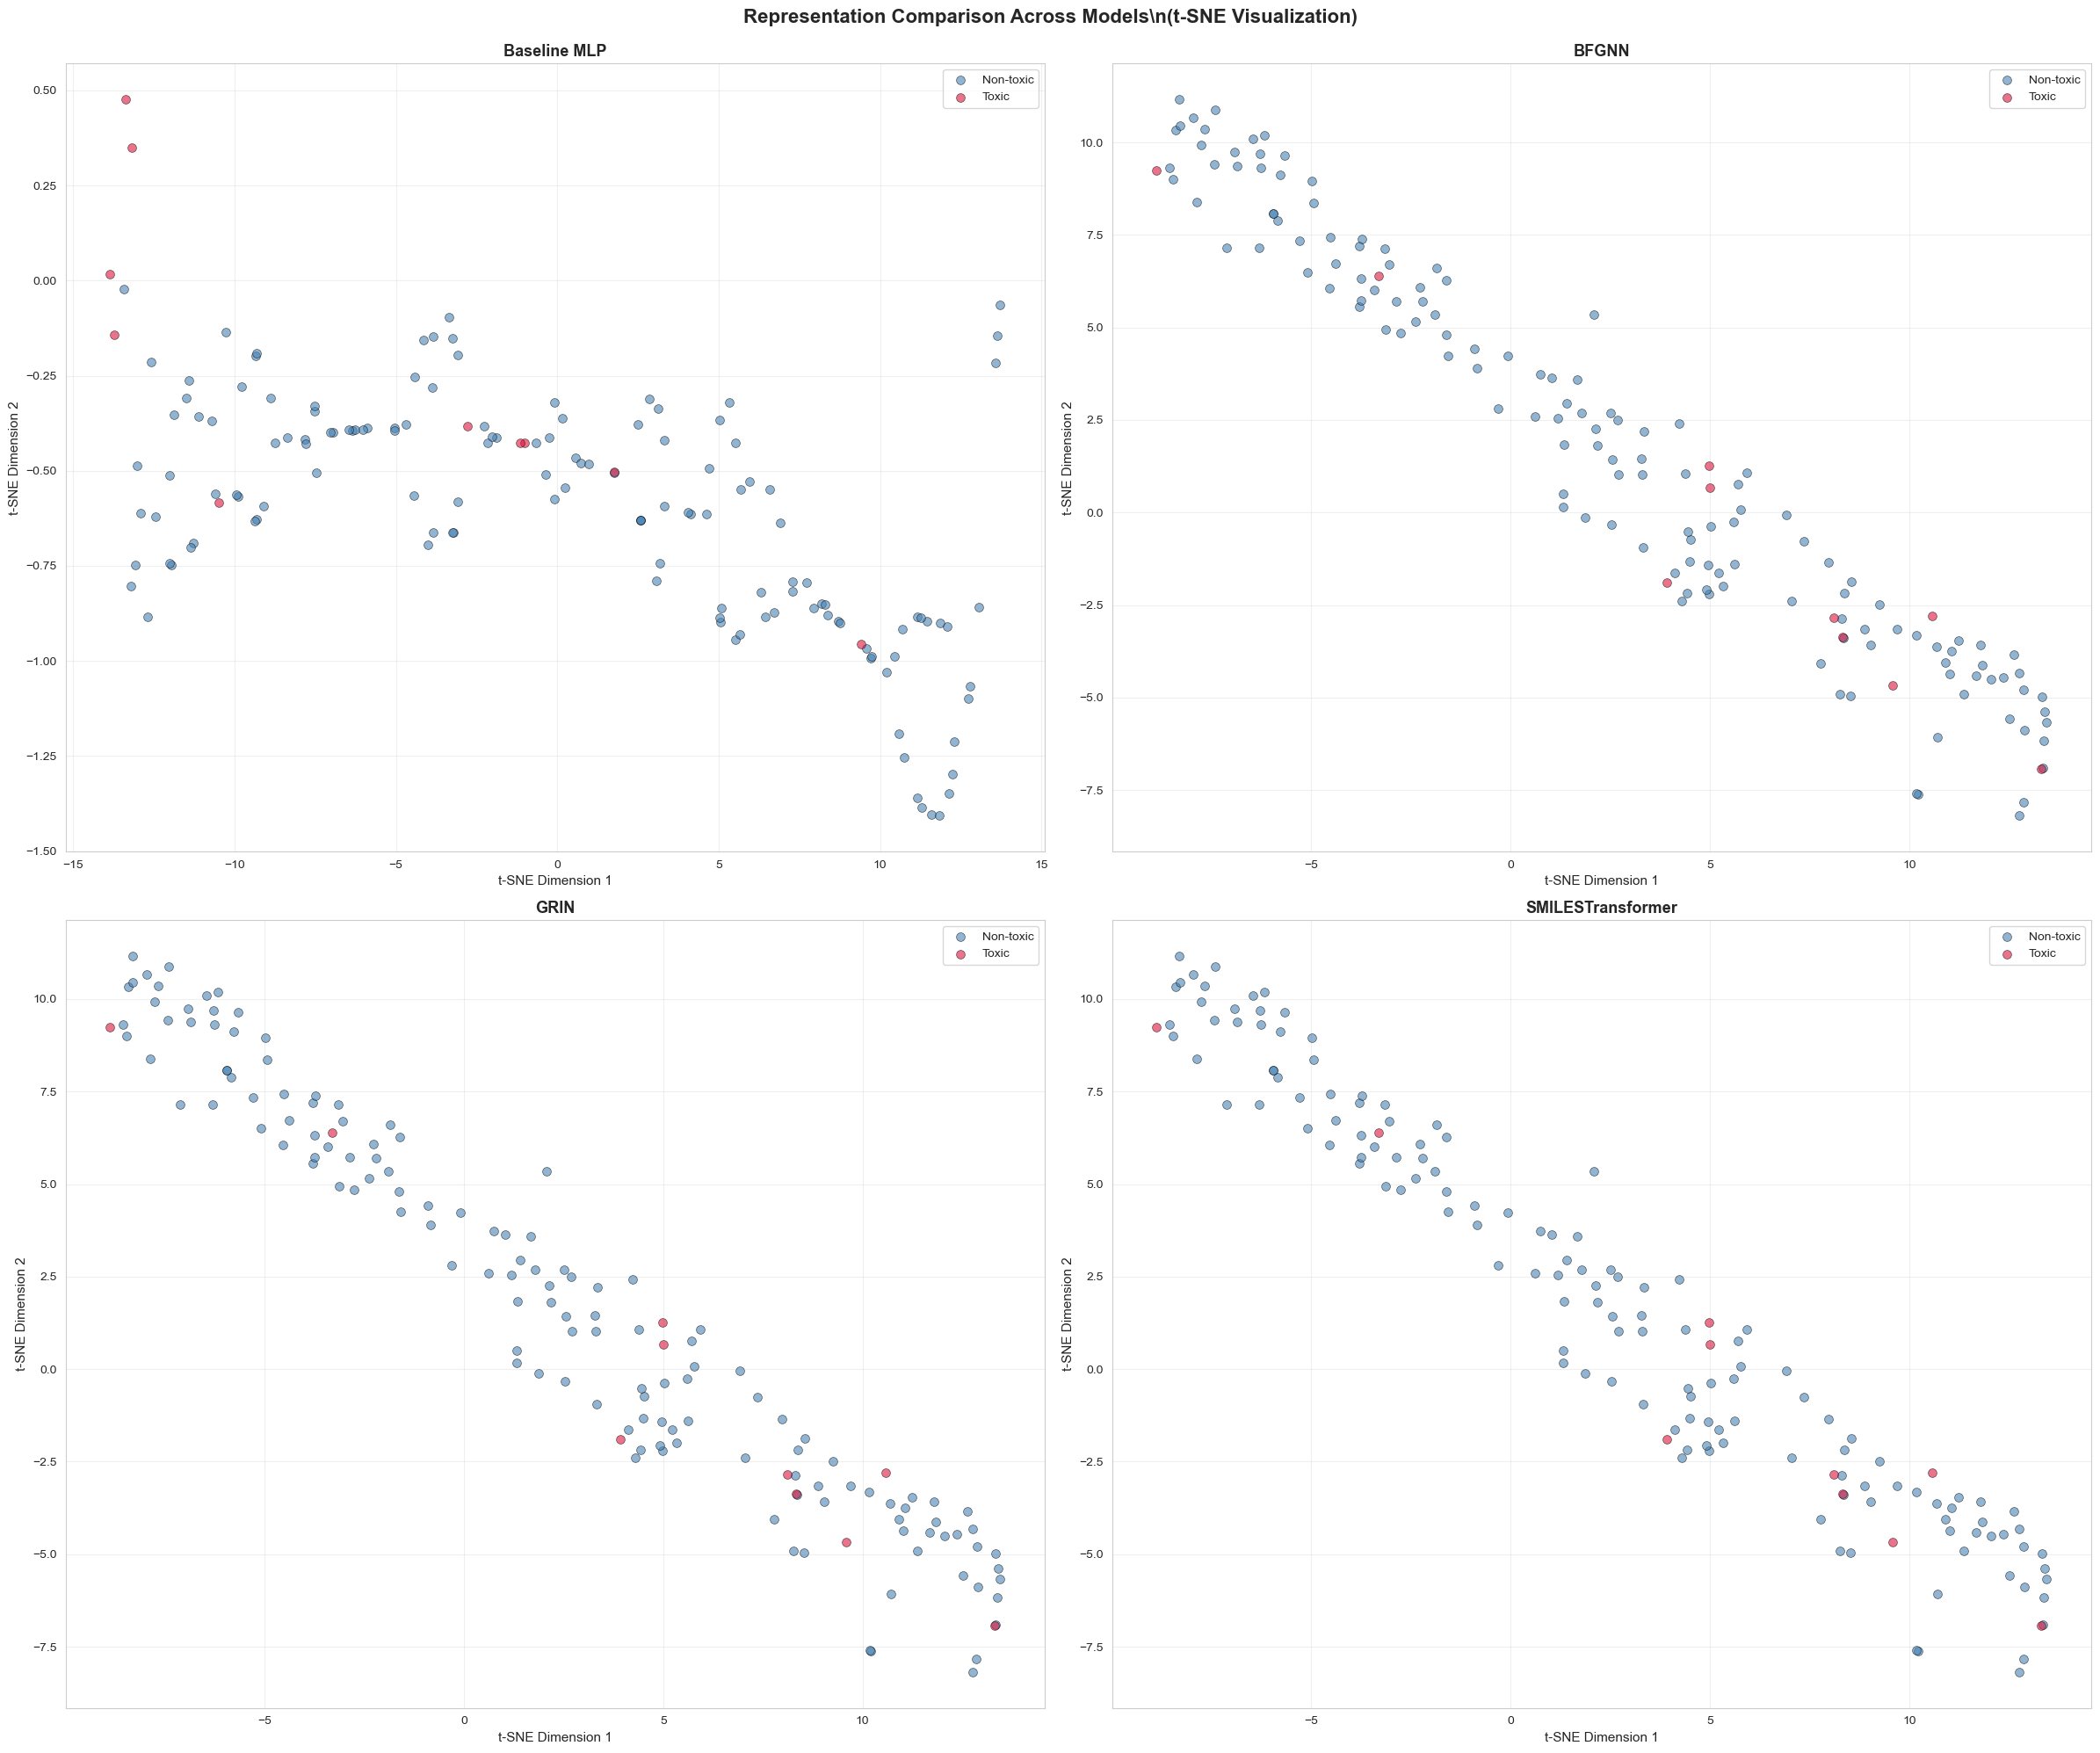

\n============================================================
✓ Comparison complete


In [14]:
# Create side-by-side comparison of all available models
available_embeddings = {}
available_names = {}

if mlp_embeddings is not None:
    available_embeddings['MLP'] = mlp_embeddings
    available_names['MLP'] = 'Baseline MLP'
if bfgnn_embeddings is not None:
    available_embeddings['BFGNN'] = bfgnn_embeddings
    available_names['BFGNN'] = 'BFGNN'
if grin_embeddings is not None:
    available_embeddings['GRIN'] = grin_embeddings
    available_names['GRIN'] = 'GRIN'
if smilestransformer_embeddings is not None:
    available_embeddings['SMILESTransformer'] = smilestransformer_embeddings
    available_names['SMILESTransformer'] = 'SMILESTransformer'

if len(available_embeddings) > 0:
    print(f"Comparing {len(available_embeddings)} model(s) side-by-side...")
    print("=" * 60)
    
    # Use t-SNE for comparison (more stable across models)
    n_models = len(available_embeddings)
    n_cols = min(2, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12 * n_cols, 10 * n_rows))
    if n_models == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, (model_key, embeddings) in enumerate(available_embeddings.items()):
        print(f"\\nProcessing {available_names[model_key]}...")
        
        # Reduce dimensions
        reduced = reduce_dimensions(embeddings, method='tsne', perplexity=30, n_iter=1000)
        
        # Plot
        ax = axes[idx]
        toxic_mask = labels == 1
        nontoxic_mask = labels == 0
        
        if np.any(nontoxic_mask):
            ax.scatter(
                reduced[nontoxic_mask, 0],
                reduced[nontoxic_mask, 1],
                c='steelblue',
                label='Non-toxic',
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )
        
        if np.any(toxic_mask):
            ax.scatter(
                reduced[toxic_mask, 0],
                reduced[toxic_mask, 1],
                c='crimson',
                label='Toxic',
                alpha=0.6,
                s=50,
                edgecolors='black',
                linewidth=0.5
            )
        
        ax.set_xlabel('t-SNE Dimension 1', fontsize=11)
        ax.set_ylabel('t-SNE Dimension 2', fontsize=11)
        ax.set_title(f'{available_names[model_key]}', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_models, len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle('Representation Comparison Across Models\\n(t-SNE Visualization)', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    
    # Save
    figures_dir = project_root / "output" / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_dir / "06_all_models_representation_comparison.png", dpi=300, bbox_inches='tight')
    print(f"\\n✓ Comparison saved to: {figures_dir / '06_all_models_representation_comparison.png'}")
    
    plt.show()
    print("\\n" + "=" * 60)
    print("✓ Comparison complete")
else:
    print("⚠ No embeddings available for comparison")


## Summary

This notebook has visualized the feature representations learned by all trained models:

✓ **Baseline MLP**: Fingerprint-based embeddings from the feature layer  
✓ **BFGNN**: Graph neural network embeddings  
✓ **GRIN**: Repetition-invariant graph neural network embeddings  
✓ **SMILESTransformer**: Sequence-based embeddings  

**Key Observations:**

1. **Representation Diversity**: Each model architecture learns different representations
2. **Clustering Quality**: Well-trained models show separation between toxic and non-toxic molecules
3. **Model Complementarity**: Different representations capture complementary information
4. **Visualization Limitations**: 2D projections provide approximate views of high-dimensional spaces

**Next Steps:**

- Analyze clustering quality quantitatively
- Investigate molecules in unexpected embedding regions
- Use embeddings for downstream tasks
- Compare embedding spaces with quantitative metrics
